# Notebook 07 — Results, Metrics & Visualisation

## Toxicity Detection & Gender/Race Bias Analysis

**Purpose:** This is the final, analysis-only notebook for the project. It brings together the results of **Notebook 04 (DeBERTa-v3-base training), Notebook 05 (Jigsaw gender/race validation + toxicity inference), and Notebook 06 (Bluesky toxicity/bias inference)** 

### What this notebook produces

- Model-performance tables and  metrics from Notebook 04.
- Validation metrics independently recomputed from Notebook 05's saved validation parquet.
- Gender/race keyword precision, recall and F1 analysis.
- Jigsaw toxicity comparisons using annotation-based and keyword-based groups.
- Bluesky toxicity distributions and gender/race group comparisons.
- Raw vs. prior-corrected toxicity-score analysis.
- Statistical comparisons, confidence intervals and effect sizes.
- Publication-quality PNG figures saved under `models/deberta_v3_base/notebook07_results/figures/`.
- CSV result tables and a generated findings Markdown report.
- A live progress log so every major analysis stage is visible while the notebook runs.

> **Important interpretation rule:** Bluesky has no human toxicity/identity ground truth in these files. Therefore, Bluesky results are **model-inferred toxicity scores and keyword-based group associations**, not measured ground-truth toxicity rates or causal evidence of bias.

## 1. Source alignment

This notebook performs statistical analysis of overall toxicity, category averages, gender-vs-race comparisons and summary trends, and produces visualisations and documentation of the dataset, methodology, preprocessing, model development, results, and gender/race bias patterns.

Notebook 07 therefore **does not retrain the model and does not alter Notebook 04–06 outputs**. It reads their saved artifacts and performs the final synthesis.

In [82]:
from pathlib import Path
import json
import math
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from tqdm.auto import tqdm
from scipy import stats
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    classification_report,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

print("Imports loaded successfully.")

Imports loaded successfully.


In [83]:
# -------------------------------------------------------------------
# Local paths
# -------------------------------------------------------------------
ROOT = Path("..")
WORK = ROOT / "models" / "deberta_v3_base" / "notebook07_results"
FIGURES = WORK / "figures"
TABLES = WORK / "tables"
REPORTS = WORK / "reports"

for d in [WORK, FIGURES, TABLES, REPORTS]:
    d.mkdir(parents=True, exist_ok=True)

# Prefer the 20K Bluesky inference artifact when available.
BLUESKY_CANDIDATES = [
    ROOT / "models" / "deberta_v3_base" / "predictions" / "bluesky_toxicity_bias_inference_sample20000.parquet",
    ROOT / "models" / "deberta_v3_base" / "predictions" / "bluesky_toxicity_bias_inference_sample200000.parquet",
    ROOT / "models" / "deberta_v3_base" / "predictions" / "bluesky_toxicity_bias_inference_full.parquet",
]

VALIDATION_PATH = ROOT / "models" / "deberta_v3_base" / "predictions" / "jigsaw_gender_race_validation.parquet"

# Notebook 04 artifacts may be in several nested locations depending on how
# the project was packaged, so discovery is recursive.
EVAL_METRICS_FILES = list(ROOT.rglob("eval_metrics.json"))
CLASS_REPORT_FILES = list(ROOT.rglob("classification_report.json"))
RUN_SUMMARY_FILES = list(ROOT.rglob("run_summary.json"))
HISTORY_FILES = list(ROOT.rglob("training_history.csv"))
VALIDATION_PREDICTION_FILES = list(ROOT.rglob("validation_predictions.csv"))
SOURCE_FIGURE_FILES = [
    p for p in ROOT.rglob("*.png")
    if "notebook07_results" not in str(p)
]

BLUESKY_PATH = next((p for p in BLUESKY_CANDIDATES if p.exists()), None)

print("Dataset root:", ROOT)
print("Validation file:", VALIDATION_PATH, VALIDATION_PATH.exists())
print("Preferred Bluesky file:", BLUESKY_PATH)
print("Notebook 04 eval metric files found:", len(EVAL_METRICS_FILES))
print("Notebook 04 classification reports found:", len(CLASS_REPORT_FILES))
print("Notebook 04 run summaries found:", len(RUN_SUMMARY_FILES))
print("Notebook 04 training histories found:", len(HISTORY_FILES))
print("Notebook 04 validation prediction files found:", len(VALIDATION_PREDICTION_FILES))
print("Source PNG figures found:", len(SOURCE_FIGURE_FILES))

Dataset root: /kaggle/input/datasets/tzmughal/social-toxic-sentimental-dataset
Validation file: /kaggle/input/datasets/tzmughal/social-toxic-sentimental-dataset/jigsaw_gender_race_validation.parquet True
Preferred Bluesky file: /kaggle/input/datasets/tzmughal/social-toxic-sentimental-dataset/bluesky_toxicity_bias_inference_sample20000.parquet
Notebook 04 eval metric files found: 1
Notebook 04 classification reports found: 1
Notebook 04 run summaries found: 1
Notebook 04 training histories found: 1
Notebook 04 validation prediction files found: 1
Source PNG figures found: 4


## 2. Live progress tracking

Every major stage below records start/end time and status. This is intentionally simple and visible in notebook output, so a long analysis run can be monitored without guessing which section is executing.

In [84]:
RUN_LOG = []

def stage(name):
    print("\n" + "=" * 78)
    print(f"[START] {name}")
    print("=" * 78)
    t0 = time.time()
    return t0

def finish_stage(name, t0, note=""):
    elapsed = time.time() - t0
    RUN_LOG.append({
        "stage": name,
        "status": "completed",
        "seconds": round(elapsed, 3),
        "minutes": round(elapsed / 60, 3),
        "note": note,
    })
    print(f"[DONE ] {name} — {elapsed:.2f}s")
    if note:
        print("        ", note)

def save_table(df, filename):
    path = TABLES / filename
    df.to_csv(path, index=False)
    print("Saved:", path)
    return path

## 3. Source integrity checks

The final notebook is designed to fail loudly if a required input is missing rather than silently substituting another dataset. The 20,000-row Bluesky artifact is preferred when available; otherwise, the notebook falls back to the 200,000-row Notebook 06 sample.

In [85]:
t0 = stage("Source integrity checks")

assert ROOT.exists(), f"Kaggle dataset root not found: {ROOT}"
assert VALIDATION_PATH.exists(), (
    "Notebook 05 output is missing. Add jigsaw_gender_race_validation.parquet "
    "to the Kaggle dataset before running Notebook 07."
)
assert BLUESKY_PATH is not None, (
    "No supported Bluesky inference parquet was found. Expected one of: "
    + ", ".join(str(p) for p in BLUESKY_CANDIDATES)
)

print("Validation:", VALIDATION_PATH)
print("Bluesky inference:", BLUESKY_PATH)

finish_stage("Source integrity checks", t0)


[START] Source integrity checks
Validation: /kaggle/input/datasets/tzmughal/social-toxic-sentimental-dataset/jigsaw_gender_race_validation.parquet
Bluesky inference: /kaggle/input/datasets/tzmughal/social-toxic-sentimental-dataset/bluesky_toxicity_bias_inference_sample20000.parquet
[DONE ] Source integrity checks — 0.00s


## 4. Notebook 04 — model-training results

Notebook 04 fine-tuned **microsoft/DeBERTa-v3-base** using the balanced training/validation setup and selected the best model using validation F1. The notebook saved evaluation metrics, classification reports, ROC/PR curves, confusion matrix, training history and validation predictions.

This section first loads the saved JSON/CSV artifacts. If the metrics JSON files are unavailable, the values printed by the executed Notebook 04 are used as a clearly labelled fallback.

In [86]:
t0 = stage("Load Notebook 04 model metrics")

# Fallback values are taken directly from the executed Notebook 04 output.
NB04_FALLBACK = {
    "eval_loss": 0.36473387479782104,
    "eval_accuracy": 0.89445,
    "eval_precision": 0.8673060806406555,
    "eval_recall": 0.9314,
    "eval_f1": 0.8982110998601668,
    "eval_roc_auc": 0.961143735,
    "train_runtime": 6731.7631,
    "train_loss": 0.5434,
    "epoch": 4.0,
    "training_examples": 80000,
    "validation_examples": 20000,
    "learning_rate": 2e-5,
    "physical_batch_size": 8,
    "gradient_accumulation_steps": 2,
    "effective_batch_size": 16,
    "max_sequence_length": 384,
}

def first_json(paths):
    for p in paths:
        if p.exists():
            try:
                with open(p, "r", encoding="utf-8") as f:
                    return json.load(f), p
            except Exception:
                pass
    return None, None

eval_json, eval_path = first_json(EVAL_METRICS_FILES)
summary_json, summary_path = first_json(RUN_SUMMARY_FILES)
class_json, class_path = first_json(CLASS_REPORT_FILES)

nb04_metrics = NB04_FALLBACK.copy()

if eval_json and any(k in eval_json for k in ["eval_f1", "eval_roc_auc", "eval_accuracy"]):
    nb04_metrics.update(eval_json)
    print("Loaded Notebook 04 evaluation metrics from:", eval_path)
else:
    print("Notebook 04 eval_metrics.json not found in Kaggle input; using executed Notebook 04 values.")

if summary_json:
    nb04_metrics.update({
        k: v for k, v in summary_json.items()
        if k in ["training_examples", "validation_examples", "learning_rate",
                 "physical_batch_size", "gradient_accumulation_steps",
                 "effective_batch_size", "training_time_seconds"]
    })
    if "final_eval_metrics" in summary_json:
        nb04_metrics.update(summary_json["final_eval_metrics"])

nb04_metrics
nb04_predictions_path = None
for p in VALIDATION_PREDICTION_FILES:
    if "deberta" in str(p).lower():
        nb04_predictions_path = p
        break
if nb04_predictions_path is None and VALIDATION_PREDICTION_FILES:
    nb04_predictions_path = VALIDATION_PREDICTION_FILES[0]
if nb04_predictions_path is not None:
    try:
        cols = pd.read_csv(nb04_predictions_path, nrows=2).columns
        needed = {"true_label", "predicted_label", "predicted_probability_toxic"}
        if needed.issubset(set(cols)):
            print("Notebook 04 validation predictions:", nb04_predictions_path)
        else:
            print("Ignoring prediction file with unexpected schema:", nb04_predictions_path)
            nb04_predictions_path = None
    except Exception as exc:
        print("Could not inspect Notebook 04 predictions:", exc)
        nb04_predictions_path = None
else:
    print("Notebook 04 validation_predictions.csv not found; using Notebook 05 validation for curve fallback.")



[START] Load Notebook 04 model metrics
Loaded Notebook 04 evaluation metrics from: /kaggle/input/datasets/tzmughal/social-toxic-sentimental-dataset/deberta_v3_base/deberta_v3_base/reports/eval_metrics.json
Notebook 04 validation predictions: /kaggle/input/datasets/tzmughal/social-toxic-sentimental-dataset/deberta_v3_base/deberta_v3_base/predictions/validation_predictions.csv


In [87]:
model_metric_rows = [
    ["Accuracy", nb04_metrics.get("eval_accuracy")],
    ["Precision", nb04_metrics.get("eval_precision")],
    ["Recall", nb04_metrics.get("eval_recall")],
    ["F1", nb04_metrics.get("eval_f1")],
    ["ROC-AUC", nb04_metrics.get("eval_roc_auc")],
    ["Validation loss", nb04_metrics.get("eval_loss")],
    ["Training loss", nb04_metrics.get("train_loss")],
]
model_metrics_df = pd.DataFrame(model_metric_rows, columns=["Metric", "Value"])

display(model_metrics_df)
save_table(model_metrics_df, "01_notebook04_model_metrics.csv")

print("\nTraining configuration:")
print(f"  Training examples      : {nb04_metrics.get('training_examples'):,}")
print(f"  Validation examples    : {nb04_metrics.get('validation_examples'):,}")
print(f"  Epochs                 : {nb04_metrics.get('epoch')}")
print(f"  Learning rate          : {nb04_metrics.get('learning_rate')}")
print(f"  Physical batch size    : {nb04_metrics.get('physical_batch_size')}")
print(f"  Gradient accumulation  : {nb04_metrics.get('gradient_accumulation_steps')}")
print(f"  Effective batch size   : {nb04_metrics.get('effective_batch_size')}")
print(f"  Max sequence length    : {nb04_metrics.get('max_sequence_length')}")

,Metric,Value
0,Accuracy,0.894450
1,Precision,0.867306
2,Recall,0.931400
3,F1,0.898211
4,ROC-AUC,0.961144
5,Validation loss,0.364734
6,Training loss,0.543400


Saved: /kaggle/working/notebook07_project_results/tables/01_notebook04_model_metrics.csv

Training configuration:
  Training examples      : 80,000
  Validation examples    : 20,000
  Epochs                 : 4.0
  Learning rate          : 2e-05
  Physical batch size    : 8
  Gradient accumulation  : 2
  Effective batch size   : 16
  Max sequence length    : 384


### Interpretation — Notebook 04

The official Notebook 04 evaluation metrics are loaded from the saved evaluation artifact when available; otherwise the notebook uses the explicitly documented fallback values from the completed run.

The key reported metrics are shown in the table above:

- **F1:** the saved/fallback Notebook 04 value
- **ROC-AUC:** the saved/fallback Notebook 04 value
- **Precision, recall and accuracy:** the saved/fallback Notebook 04 values

These metrics describe performance on the **Jigsaw validation distribution used for model evaluation**. They must not be presented as accuracy/F1 on Bluesky, because Bluesky has no equivalent human-labelled toxicity ground truth in the inference data.

The later Bluesky analysis is therefore an analysis of **model-inferred toxicity scores**, not a separately validated toxicity classifier on Bluesky.



[START] Plot Notebook 04 model metrics


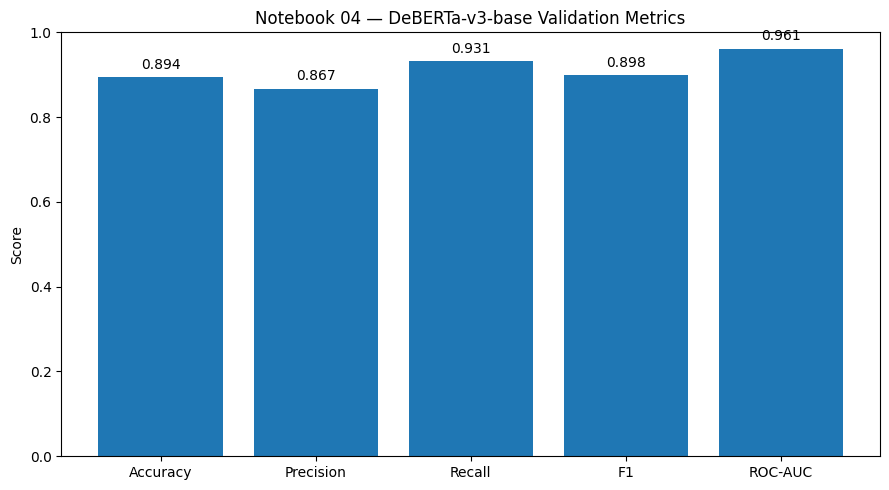

Saved: /kaggle/working/notebook07_project_results/figures/01_model_validation_metrics.png
[DONE ] Plot Notebook 04 model metrics — 0.44s


In [88]:
t0 = stage("Plot Notebook 04 model metrics")

plot_df = model_metrics_df[model_metrics_df["Metric"].isin(
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
)].copy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(plot_df["Metric"], plot_df["Value"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Notebook 04 — DeBERTa-v3-base Validation Metrics")
for i, v in enumerate(plot_df["Value"]):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
path = FIGURES / "01_model_validation_metrics.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)

finish_stage("Plot Notebook 04 model metrics", t0)

### Notebook 04 training history

If `training_history.csv` was included with the model artifacts, Notebook 07 reproduces the training-loss and validation-F1 trajectory. 


[START] Plot Notebook 04 training history
Loaded: /kaggle/input/datasets/tzmughal/social-toxic-sentimental-dataset/deberta_v3_base/deberta_v3_base/reports/training_history.csv


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_roc_auc,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.397782,13.742621,0.000001,0.020000,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.383263,12.076327,0.000002,0.040000,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.358339,15.965135,0.000003,0.060000,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.282460,13.808308,0.000004,0.080000,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.195165,29.215612,0.000005,0.100000,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


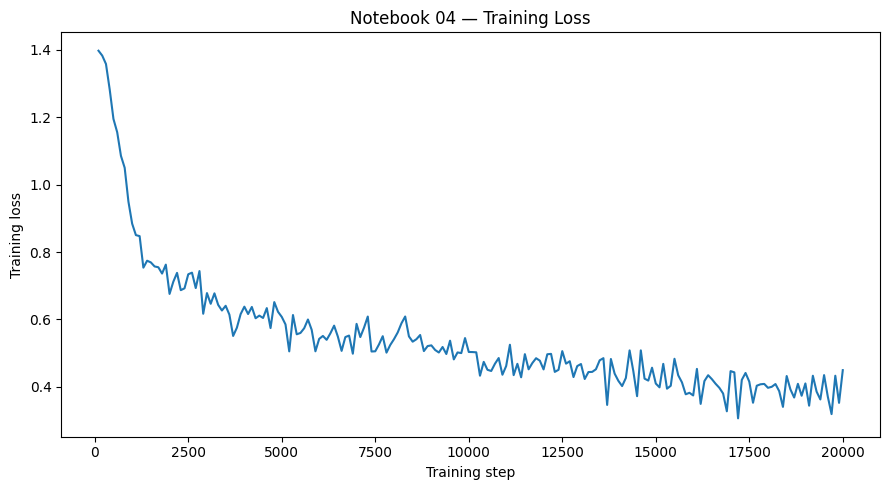

Saved: /kaggle/working/notebook07_project_results/figures/01b_model_training_loss.png


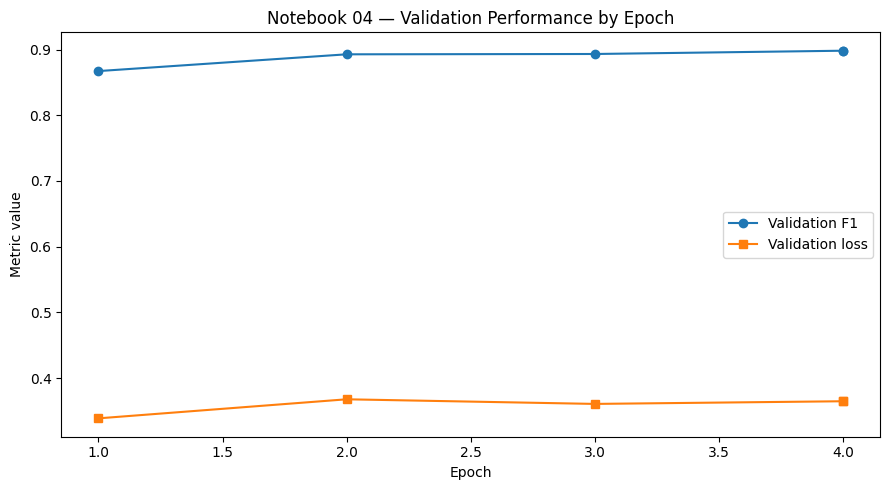

Saved: /kaggle/working/notebook07_project_results/figures/01c_model_validation_history.png
Saved: /kaggle/working/notebook07_project_results/tables/01_notebook04_training_history.csv
[DONE ] Plot Notebook 04 training history — 0.97s


In [89]:
t0 = stage("Plot Notebook 04 training history")

history_path = next((p for p in HISTORY_FILES if p.exists()), None)

if history_path is None:
    print("Notebook 04 training_history.csv was not found in the Kaggle dataset.")
    print("The final evaluation metrics remain available; training-history plotting is skipped.")
else:
    history = pd.read_csv(history_path)
    print("Loaded:", history_path)
    display(history.head())

    train_logs = history[history["loss"].notna()].copy() if "loss" in history.columns else pd.DataFrame()
    eval_logs = history[history["eval_f1"].notna()].copy() if "eval_f1" in history.columns else pd.DataFrame()

    if not train_logs.empty:
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(train_logs["step"], train_logs["loss"])
        ax.set_xlabel("Training step")
        ax.set_ylabel("Training loss")
        ax.set_title("Notebook 04 — Training Loss")
        plt.tight_layout()
        path = FIGURES / "01b_model_training_loss.png"
        plt.savefig(path, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", path)

    if not eval_logs.empty:
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(eval_logs["epoch"], eval_logs["eval_f1"], marker="o", label="Validation F1")
        if "eval_loss" in eval_logs.columns:
            ax.plot(eval_logs["epoch"], eval_logs["eval_loss"], marker="s", label="Validation loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Metric value")
        ax.set_title("Notebook 04 — Validation Performance by Epoch")
        ax.legend()
        plt.tight_layout()
        path = FIGURES / "01c_model_validation_history.png"
        plt.savefig(path, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", path)

    save_table(history, "01_notebook04_training_history.csv")

finish_stage("Plot Notebook 04 training history", t0)

## 5. Notebook 05 — Jigsaw validation and keyword methodology

Notebook 05 combines:

1. Jigsaw identity annotations as the ground-truth reference for gender/race relevance.
2. The keyword lists.
3. DeBERTa toxicity scores.
4. Annotation-based and keyword-based group comparisons.

The notebook found that the original gender list was heavily affected by bare pronouns. It therefore adopted the **trimmed 28-term gender list**, dropping `he/him/his/she/her/hers/they/them/theirs`. The race list remained unchanged at 40 terms.

The final Bluesky analysis uses the refined gender list, while the original list remains documented as a validation comparison.

In [90]:
t0 = stage("Load Notebook 05 validation data")

validation = pd.read_parquet(VALIDATION_PATH)
print("Shape:", validation.shape)
print("Columns:", validation.columns.tolist())

required = [
    "clean_text", "is_toxic", "pred_prob", "pred_label",
    "gender_related_annot", "race_related_annot",
    "gender_related_kw", "gender_related_kw_full", "race_related_kw"
]
missing = [c for c in required if c not in validation.columns]
assert not missing, f"Notebook 05 output is missing required columns: {missing}"

print("\nToxicity label distribution:")
print(validation["is_toxic"].value_counts(dropna=False))

print("\nKeyword flag counts:")
for c in ["gender_related_kw", "gender_related_kw_full", "race_related_kw"]:
    print(f"{c}: {validation[c].sum():,} flagged / {len(validation):,}")

finish_stage("Load Notebook 05 validation data", t0)


[START] Load Notebook 05 validation data
Shape: (19987, 21)
Columns: ['id', 'comment_text', 'clean_text', 'target', 'is_toxic', 'gender_related_annot', 'race_related_annot', 'gender_related_kw', 'gender_related_kw_full', 'race_related_kw', 'pred_prob', 'pred_label', 'female', 'male', 'transgender', 'other_gender', 'black', 'white', 'asian', 'latino', 'other_race_or_ethnicity']

Toxicity label distribution:
is_toxic
0    10000
1     9987
Name: count, dtype: int64

Keyword flag counts:
gender_related_kw: 2,479 flagged / 19,987
gender_related_kw_full: 10,116 flagged / 19,987
race_related_kw: 1,924 flagged / 19,987
[DONE ] Load Notebook 05 validation data — 0.06s


In [91]:
t0 = stage("Recompute Notebook 05 validation metrics")

y_true = validation["is_toxic"].astype(int).to_numpy()
y_pred = validation["pred_label"].astype(int).to_numpy()
y_prob = validation["pred_prob"].astype(float).to_numpy()

nb05_metrics = pd.DataFrame([{
    "dataset": "Notebook 05 saved validation output",
    "n": len(validation),
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "f1": f1_score(y_true, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_true, y_prob),
    "average_precision": average_precision_score(y_true, y_prob),
}])

display(nb05_metrics)
save_table(nb05_metrics, "02_notebook05_validation_metrics_recomputed.csv")

print("\nClassification report:")
print(classification_report(
    y_true, y_pred,
    target_names=["Non-Toxic", "Toxic"],
    digits=4,
    zero_division=0
))

finish_stage("Recompute Notebook 05 validation metrics", t0)


[START] Recompute Notebook 05 validation metrics


,dataset,n,accuracy,precision,recall,f1,roc_auc,average_precision
0,Notebook 05 saved validation output,19987,0.894281,0.866710,0.931711,0.898036,0.960757,0.957188


Saved: /kaggle/working/notebook07_project_results/tables/02_notebook05_validation_metrics_recomputed.csv

Classification report:
              precision    recall  f1-score   support

   Non-Toxic     0.9263    0.8569    0.8902     10000
       Toxic     0.8667    0.9317    0.8980      9987

    accuracy                         0.8943     19987
   macro avg     0.8965    0.8943    0.8941     19987
weighted avg     0.8965    0.8943    0.8941     19987

[DONE ] Recompute Notebook 05 validation metrics — 0.04s


### Notebook 04 vs Notebook 05 validation note

Notebook 04 evaluated the full 20,000-row validation split directly and reported the official model metrics. Notebook 05's saved output contains **19,987 rows**, because its join back to `jigsaw_processed.parquet` was performed on `clean_text` and did not recover all 20,000 validation rows. Therefore, Notebook 07 keeps these as two related but distinct views rather than silently claiming they are identical samples.


[START] Plot validation confusion matrix and ROC/PR curves


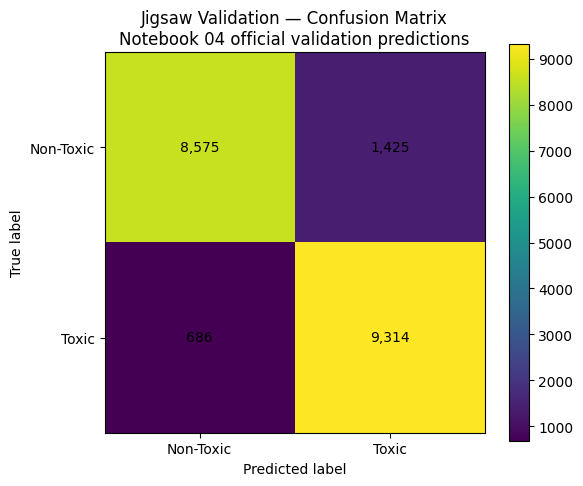

Saved: /kaggle/working/notebook07_project_results/figures/02_jigsaw_confusion_matrix.png


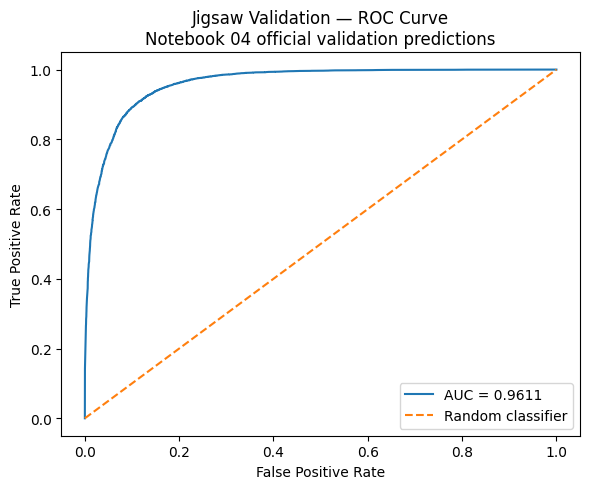

Saved: /kaggle/working/notebook07_project_results/figures/03_jigsaw_roc_curve.png


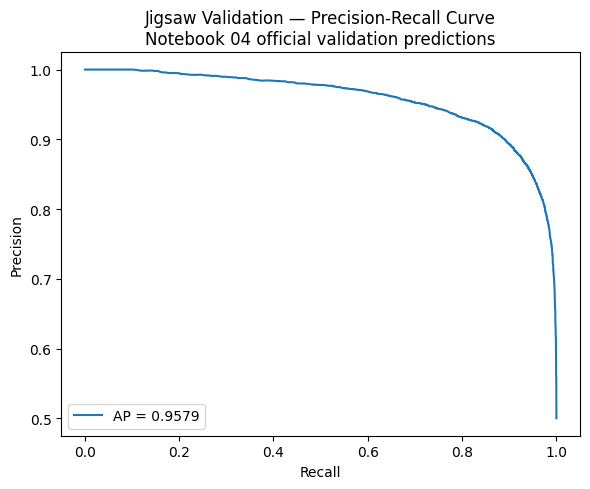

Saved: /kaggle/working/notebook07_project_results/figures/04_jigsaw_precision_recall_curve.png


,source,n,accuracy,precision,recall,f1,roc_auc,average_precision
0,Notebook 04 official validation predictions,20000,0.894450,0.867306,0.931400,0.898211,0.961144,0.957888


Saved: /kaggle/working/notebook07_project_results/tables/02b_jigsaw_curve_metrics.csv
[DONE ] Plot validation confusion matrix and ROC/PR curves — 1.39s
         Notebook 04 official validation predictions


In [92]:
t0 = stage("Plot validation confusion matrix and ROC/PR curves")

if nb04_predictions_path is not None:
    official = pd.read_csv(nb04_predictions_path)
    y_true_curve = official["true_label"].astype(int).to_numpy()
    y_pred_curve = official["predicted_label"].astype(int).to_numpy()
    y_prob_curve = official["predicted_probability_toxic"].astype(float).to_numpy()
    curve_source = "Notebook 04 official validation predictions"
else:
    y_true_curve = validation["is_toxic"].astype(int).to_numpy()
    y_pred_curve = validation["pred_label"].astype(int).to_numpy()
    y_prob_curve = validation["pred_prob"].astype(float).to_numpy()
    curve_source = "Notebook 05 saved validation output (diagnostic fallback)"

cm = confusion_matrix(y_true_curve, y_pred_curve)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm)
classes = ["Non-Toxic", "Toxic"]
ax.set_xticks(range(2)); ax.set_yticks(range(2))
ax.set_xticklabels(classes); ax.set_yticklabels(classes)
ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
ax.set_title(f"Jigsaw Validation — Confusion Matrix\n{curve_source}")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], ","), ha="center", va="center")
fig.colorbar(im, ax=ax)
plt.tight_layout()
path = FIGURES / "02_jigsaw_confusion_matrix.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)

fpr, tpr, _ = roc_curve(y_true_curve, y_prob_curve)
auc_curve = roc_auc_score(y_true_curve, y_prob_curve)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"AUC = {auc_curve:.4f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title(f"Jigsaw Validation — ROC Curve\n{curve_source}")
ax.legend(loc="lower right")
plt.tight_layout()
path = FIGURES / "03_jigsaw_roc_curve.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)

precision_curve, recall_curve, _ = precision_recall_curve(y_true_curve, y_prob_curve)
ap_curve = average_precision_score(y_true_curve, y_prob_curve)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall_curve, precision_curve, label=f"AP = {ap_curve:.4f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title(f"Jigsaw Validation — Precision-Recall Curve\n{curve_source}")
ax.legend(loc="lower left")
plt.tight_layout()
path = FIGURES / "04_jigsaw_precision_recall_curve.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)

curve_metrics = pd.DataFrame([{
    "source": curve_source,
    "n": len(y_true_curve),
    "accuracy": accuracy_score(y_true_curve, y_pred_curve),
    "precision": precision_score(y_true_curve, y_pred_curve, zero_division=0),
    "recall": recall_score(y_true_curve, y_pred_curve, zero_division=0),
    "f1": f1_score(y_true_curve, y_pred_curve, zero_division=0),
    "roc_auc": auc_curve,
    "average_precision": ap_curve,
}])
display(curve_metrics)
save_table(curve_metrics, "02b_jigsaw_curve_metrics.csv")

finish_stage("Plot validation confusion matrix and ROC/PR curves", t0, note=curve_source)



[START] Validate gender/race keyword lists


,method,precision,recall,f1,flagged_n,truth_positive_n
0,Gender — original 37 terms,0.123369,0.974239,0.219005,10116,1281
1,Gender — trimmed 28 terms,0.494151,0.956284,0.651596,2479,1281
2,Race — 40 terms,0.416320,0.923875,0.573988,1924,867


Saved: /kaggle/working/notebook07_project_results/tables/03_keyword_validation_metrics.csv


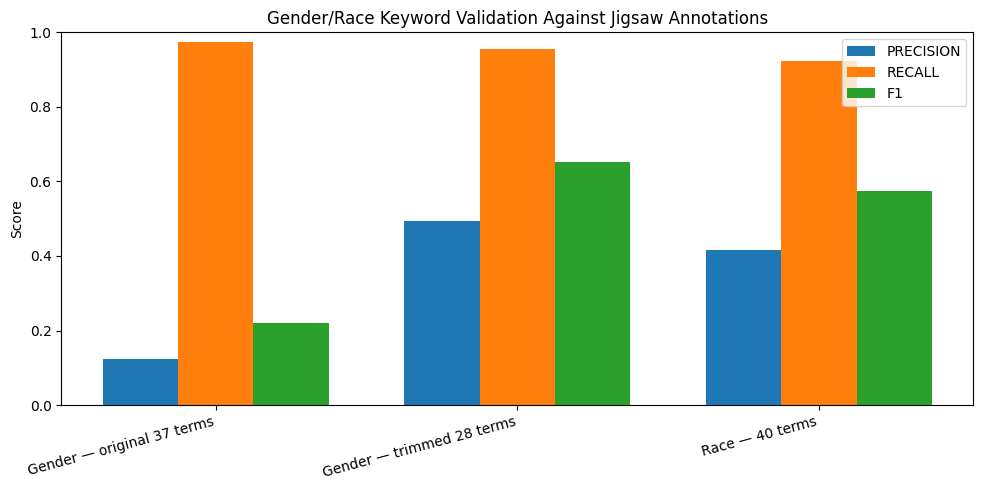

Saved: /kaggle/working/notebook07_project_results/figures/05_keyword_validation_precision_recall_f1.png
[DONE ] Validate gender/race keyword lists — 0.54s


In [93]:
t0 = stage("Validate gender/race keyword lists")

def binary_keyword_metrics(df, truth_col, pred_col, label):
    yt = df[truth_col].astype(int)
    yp = df[pred_col].astype(int)
    return {
        "method": label,
        "precision": precision_score(yt, yp, zero_division=0),
        "recall": recall_score(yt, yp, zero_division=0),
        "f1": f1_score(yt, yp, zero_division=0),
        "flagged_n": int(yp.sum()),
        "truth_positive_n": int(yt.sum()),
    }

keyword_rows = [
    binary_keyword_metrics(validation, "gender_related_annot", "gender_related_kw_full",
                           "Gender — original 37 terms"),
    binary_keyword_metrics(validation, "gender_related_annot", "gender_related_kw",
                           "Gender — trimmed 28 terms"),
    binary_keyword_metrics(validation, "race_related_annot", "race_related_kw",
                           "Race — 40 terms"),
]
keyword_metrics_df = pd.DataFrame(keyword_rows)

display(keyword_metrics_df)
save_table(keyword_metrics_df, "03_keyword_validation_metrics.csv")

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(keyword_metrics_df))
width = 0.25
for k, metric in enumerate(["precision", "recall", "f1"]):
    ax.bar(x + (k - 1) * width, keyword_metrics_df[metric], width, label=metric.upper())
ax.set_xticks(x)
ax.set_xticklabels(keyword_metrics_df["method"], rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Gender/Race Keyword Validation Against Jigsaw Annotations")
ax.legend()
plt.tight_layout()
path = FIGURES / "05_keyword_validation_precision_recall_f1.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)

finish_stage("Validate gender/race keyword lists", t0)


[START] Analyse Jigsaw toxicity by identity grouping


,analysis_group,mean,median,std,count,diff_vs_overall,relative_to_overall,grouping
0,gender_and_race,0.837448,0.982606,0.312936,206,0.306112,1.576117,Annotation-based
1,gender_only,0.688791,0.974898,0.432929,1075,0.157455,1.296338,Annotation-based
2,neither,0.506876,0.744814,0.481060,18045,-0.024461,0.953964,Annotation-based
3,race_only,0.847630,0.986383,0.306300,661,0.316294,1.595280,Annotation-based
4,gender_and_race,0.759401,0.979495,0.384080,418,0.228065,1.429229,Keyword-based
5,gender_only,0.663039,0.971959,0.443012,2061,0.131703,1.247871,Keyword-based
6,neither,0.499664,0.617098,0.482232,16002,-0.031672,0.940392,Keyword-based
7,race_only,0.624329,0.965225,0.452775,1506,0.092992,1.175016,Keyword-based


Saved: /kaggle/working/notebook07_project_results/tables/04_jigsaw_toxicity_by_group.csv


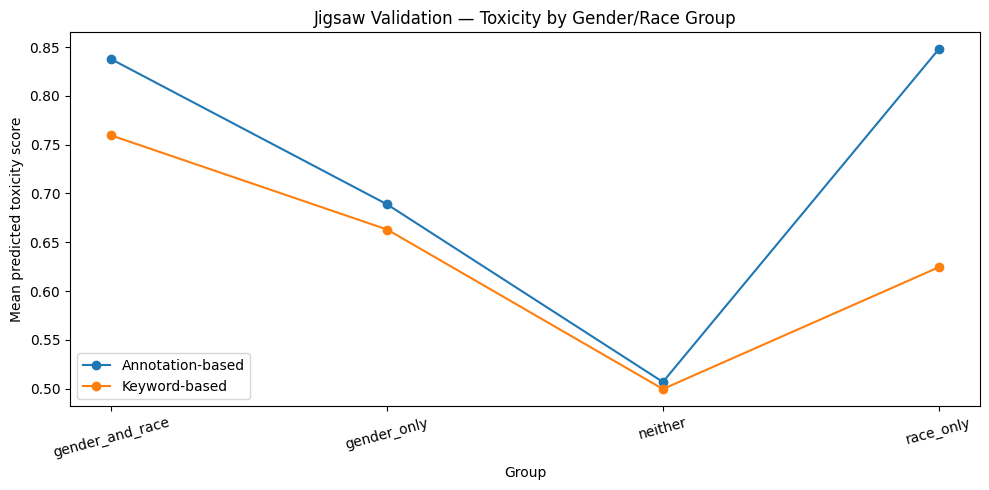

Saved: /kaggle/working/notebook07_project_results/figures/06_jigsaw_toxicity_by_identity_group.png
[DONE ] Analyse Jigsaw toxicity by identity grouping — 0.61s


In [94]:
t0 = stage("Analyse Jigsaw toxicity by identity grouping")

def make_group(df, gender_col, race_col):
    conditions = [
        (df[gender_col] == 1) & (df[race_col] == 1),
        (df[gender_col] == 1) & (df[race_col] == 0),
        (df[gender_col] == 0) & (df[race_col] == 1),
    ]
    choices = ["gender_and_race", "gender_only", "race_only"]
    return np.select(conditions, choices, default="neither")

def summary_by_group(df, gender_col, race_col, score_col="pred_prob"):
    out = df.copy()
    out["analysis_group"] = make_group(out, gender_col, race_col)
    g = out.groupby("analysis_group")[score_col].agg(["mean", "median", "std", "count"]).reset_index()
    overall = out[score_col].mean()
    g["diff_vs_overall"] = g["mean"] - overall
    g["relative_to_overall"] = g["mean"] / overall
    return g.sort_values("analysis_group")

jigsaw_annot_summary = summary_by_group(
    validation, "gender_related_annot", "race_related_annot"
).assign(grouping="Annotation-based")

jigsaw_kw_summary = summary_by_group(
    validation, "gender_related_kw", "race_related_kw"
).assign(grouping="Keyword-based")

jigsaw_group_summary = pd.concat(
    [jigsaw_annot_summary, jigsaw_kw_summary],
    ignore_index=True
)

display(jigsaw_group_summary)
save_table(jigsaw_group_summary, "04_jigsaw_toxicity_by_group.csv")

fig, ax = plt.subplots(figsize=(10, 5))
for grouping, g in jigsaw_group_summary.groupby("grouping"):
    ax.plot(g["analysis_group"], g["mean"], marker="o", label=grouping)
ax.set_ylabel("Mean predicted toxicity score")
ax.set_xlabel("Group")
ax.set_title("Jigsaw Validation — Toxicity by Gender/Race Group")
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
path = FIGURES / "06_jigsaw_toxicity_by_identity_group.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)

finish_stage("Analyse Jigsaw toxicity by identity grouping", t0)

## 6. Notebook 06 — Bluesky final inference analysis

This section analyses the Bluesky inference artifact using toxicity predictions and gender/race keyword indicators. The final analysis focuses on toxicity distributions, keyword-defined group comparisons, confidence intervals, and statistical effect sizes.


In [95]:
t0 = stage("Load final Bluesky inference artifact")

bluesky = pd.read_parquet(BLUESKY_PATH)
print("Loaded:", BLUESKY_PATH)
print("Shape:", bluesky.shape)
print("Columns:", bluesky.columns.tolist())

# The 20K Bluesky parquet contains the core inference columns:
# post_id, text, gender_related_kw, race_related_kw, pred_prob, pred_label.
# Notebook 06's richer output may additionally contain calibrated scores,
# language detection, and duplicate diagnostics. These are optional here.
required_bluesky = [
    "post_id", "text",
    "gender_related_kw", "race_related_kw",
    "pred_prob", "pred_label",
]
missing = [c for c in required_bluesky if c not in bluesky.columns]
assert not missing, f"Bluesky artifact is missing required core columns: {missing}"

# ------------------------------------------------------------------
# Backward/forward compatibility for the Bluesky artifact.
# If pred_prob_calibrated is absent, recreate exactly the prior-correction
# defined in Notebook 06. This does NOT change the raw model score.
# ------------------------------------------------------------------
if "pred_prob_calibrated" not in bluesky.columns:
    TRAIN_POS_RATE = 0.5
    TRUE_TOXIC_RATE = 0.079969

    def calibrate_prob(p, train_pos_rate=TRAIN_POS_RATE, true_pos_rate=TRUE_TOXIC_RATE):
        eps = 1e-6
        p = np.clip(np.asarray(p, dtype=float), eps, 1 - eps)
        logit = np.log(p / (1 - p))
        correction = np.log(
            (true_pos_rate / (1 - true_pos_rate))
            / (train_pos_rate / (1 - train_pos_rate))
        )
        return 1 / (1 + np.exp(-(logit + correction)))

    bluesky["pred_prob_calibrated"] = calibrate_prob(bluesky["pred_prob"].values)
    print("Derived missing 'pred_prob_calibrated' from pred_prob using Notebook 06's documented prior correction.")
else:
    print("Using existing 'pred_prob_calibrated' column from Notebook 06 output.")




[START] Load final Bluesky inference artifact
Loaded: /kaggle/input/datasets/tzmughal/social-toxic-sentimental-dataset/bluesky_toxicity_bias_inference_sample20000.parquet
Shape: (20000, 6)
Columns: ['post_id', 'text', 'gender_related_kw', 'race_related_kw', 'pred_prob', 'pred_label']
Derived missing 'pred_prob_calibrated' from pred_prob using Notebook 06's documented prior correction.


In [96]:
t0 = stage("Create Bluesky analysis groups and summary statistics")

bluesky["analysis_group"] = make_group(
    bluesky, "gender_related_kw", "race_related_kw"
)

def mean_ci(series, confidence=0.95):
    x = pd.Series(series).dropna().astype(float)
    n = len(x)
    mean = x.mean()
    if n < 2:
        return mean, np.nan, np.nan
    se = x.std(ddof=1) / np.sqrt(n)
    crit = stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean, mean - crit * se, mean + crit * se

rows = []
for group, g in bluesky.groupby("analysis_group", sort=True):
    mean_raw, lo_raw, hi_raw = mean_ci(g["pred_prob"])
    mean_cal, lo_cal, hi_cal = mean_ci(g["pred_prob_calibrated"])
    rows.append({
        "group": group,
        "n": len(g),
        "share": len(g) / len(bluesky),
        "mean_raw": mean_raw,
        "raw_ci95_low": lo_raw,
        "raw_ci95_high": hi_raw,
        "mean_calibrated": mean_cal,
        "cal_ci95_low": lo_cal,
        "cal_ci95_high": hi_cal,
        "raw_toxic_label_rate": g["pred_label"].mean(),
    })

bluesky_group_summary = pd.DataFrame(rows)

overall_raw, overall_raw_lo, overall_raw_hi = mean_ci(bluesky["pred_prob"])
overall_cal, overall_cal_lo, overall_cal_hi = mean_ci(bluesky["pred_prob_calibrated"])

bluesky_group_summary["diff_raw_vs_overall"] = (
    bluesky_group_summary["mean_raw"] - overall_raw
)
bluesky_group_summary["diff_calibrated_vs_overall"] = (
    bluesky_group_summary["mean_calibrated"] - overall_cal
)

display(bluesky_group_summary)
save_table(bluesky_group_summary, "05_bluesky_toxicity_by_group.csv")

print(f"Overall raw mean        : {overall_raw:.6f} (95% CI {overall_raw_lo:.6f}, {overall_raw_hi:.6f})")
print(f"Overall calibrated mean : {overall_cal:.6f} (95% CI {overall_cal_lo:.6f}, {overall_cal_hi:.6f})")

finish_stage("Create Bluesky analysis groups and summary statistics", t0)


[START] Create Bluesky analysis groups and summary statistics


,group,n,share,mean_raw,raw_ci95_low,raw_ci95_high,mean_calibrated,cal_ci95_low,cal_ci95_high,raw_toxic_label_rate,diff_raw_vs_overall,diff_calibrated_vs_overall
0,gender_and_race,35,0.001750,0.491982,0.336402,0.647561,0.365482,0.220529,0.510436,0.514286,0.386504,0.285624
1,gender_only,758,0.037900,0.248987,0.219896,0.278077,0.190446,0.165490,0.215402,0.246702,0.143509,0.110588
2,neither,18992,0.949600,0.097106,0.093114,0.101098,0.073472,0.070118,0.076826,0.095409,-0.008372,-0.006386
3,race_only,215,0.010750,0.276127,0.219207,0.333047,0.207623,0.159941,0.255304,0.274419,0.170650,0.127765


Saved: /kaggle/working/notebook07_project_results/tables/05_bluesky_toxicity_by_group.csv
Overall raw mean        : 0.105478 (95% CI 0.101441, 0.109514)
Overall calibrated mean : 0.079858 (95% CI 0.076466, 0.083251)
[DONE ] Create Bluesky analysis groups and summary statistics — 0.03s



[START] Plot Bluesky toxicity distributions


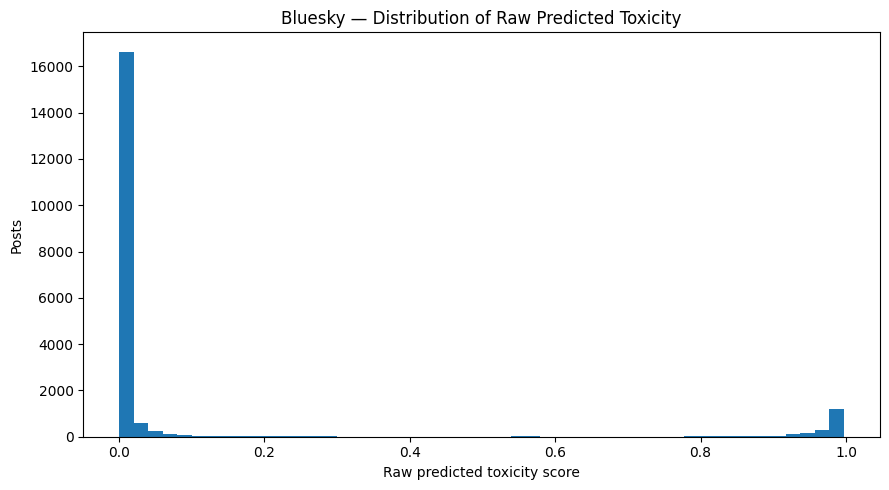

Saved: /kaggle/working/notebook07_project_results/figures/07_bluesky_raw_toxicity_distribution.png


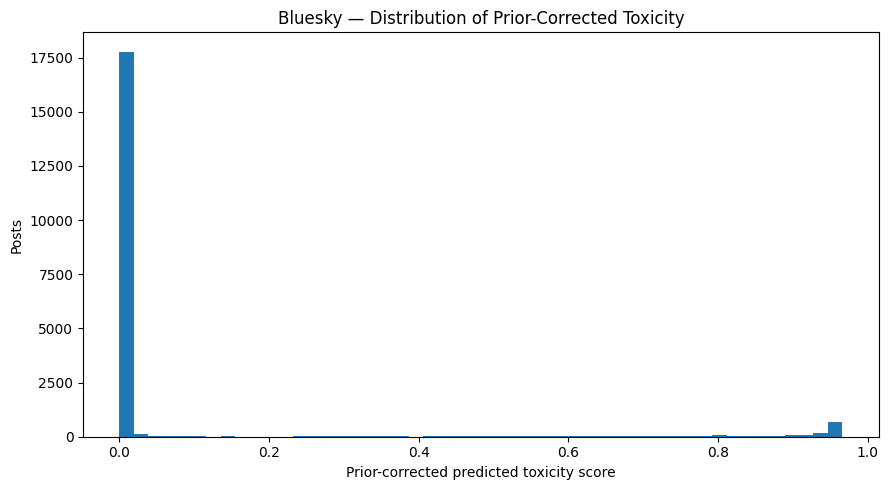

Saved: /kaggle/working/notebook07_project_results/figures/08_bluesky_calibrated_toxicity_distribution.png
[DONE ] Plot Bluesky toxicity distributions — 0.99s


In [97]:
t0 = stage("Plot Bluesky toxicity distributions")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(bluesky["pred_prob"].clip(0, 1), bins=50)
ax.set_xlabel("Raw predicted toxicity score")
ax.set_ylabel("Posts")
ax.set_title("Bluesky — Distribution of Raw Predicted Toxicity")
plt.tight_layout()
path = FIGURES / "07_bluesky_raw_toxicity_distribution.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(bluesky["pred_prob_calibrated"].clip(0, 1), bins=50)
ax.set_xlabel("Prior-corrected predicted toxicity score")
ax.set_ylabel("Posts")
ax.set_title("Bluesky — Distribution of Prior-Corrected Toxicity")
plt.tight_layout()
path = FIGURES / "08_bluesky_calibrated_toxicity_distribution.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)

finish_stage("Plot Bluesky toxicity distributions", t0)


[START] Plot Bluesky gender/race group comparisons


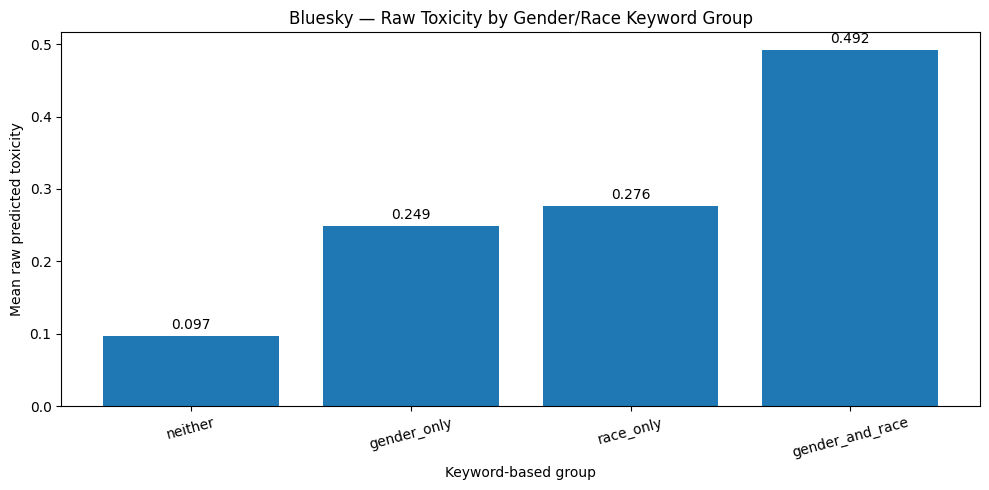

Saved: /kaggle/working/notebook07_project_results/figures/09_bluesky_raw_toxicity_by_group.png


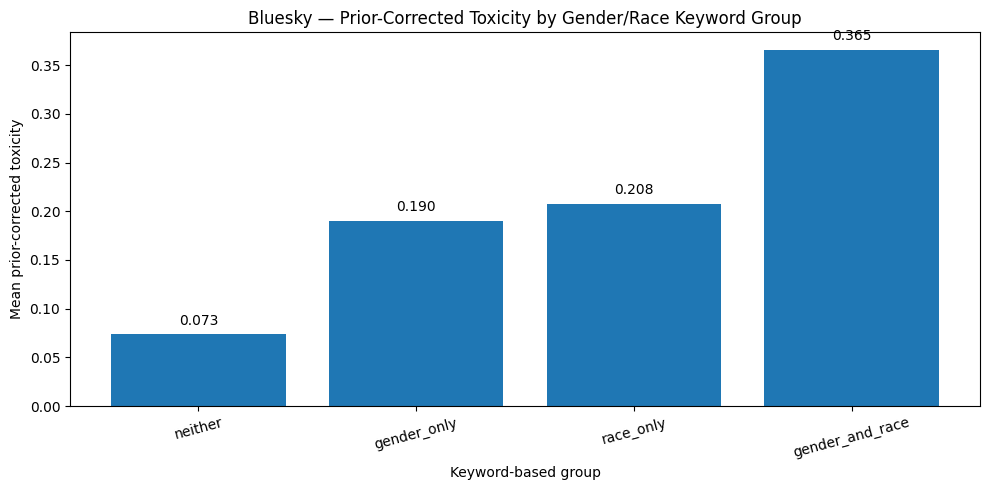

Saved: /kaggle/working/notebook07_project_results/figures/10_bluesky_calibrated_toxicity_by_group.png
[DONE ] Plot Bluesky gender/race group comparisons — 0.97s


In [98]:
t0 = stage("Plot Bluesky gender/race group comparisons")

order = ["neither", "gender_only", "race_only", "gender_and_race"]
plot_df = bluesky_group_summary.set_index("group").reindex(order).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_df["group"], plot_df["mean_raw"])
ax.set_ylabel("Mean raw predicted toxicity")
ax.set_xlabel("Keyword-based group")
ax.set_title("Bluesky — Raw Toxicity by Gender/Race Keyword Group")
for i, v in enumerate(plot_df["mean_raw"]):
    if pd.notna(v):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.xticks(rotation=15)
plt.tight_layout()
path = FIGURES / "09_bluesky_raw_toxicity_by_group.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_df["group"], plot_df["mean_calibrated"])
ax.set_ylabel("Mean prior-corrected toxicity")
ax.set_xlabel("Keyword-based group")
ax.set_title("Bluesky — Prior-Corrected Toxicity by Gender/Race Keyword Group")
for i, v in enumerate(plot_df["mean_calibrated"]):
    if pd.notna(v):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.xticks(rotation=15)
plt.tight_layout()
path = FIGURES / "10_bluesky_calibrated_toxicity_by_group.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)

finish_stage("Plot Bluesky gender/race group comparisons", t0)

## 7. Statistical testing

Because Bluesky toxicity scores are model outputs rather than human labels, these tests quantify **differences in model scores between observed keyword groups**. They do not prove that the groups have different true toxicity rates.

For each comparison, the notebook reports:

- group means and medians,
- mean difference,
- Welch's t-test,
- Mann–Whitney U test,
- Cohen's *d* effect size.

With large samples, p-values can become extremely small even for modest effects. The **magnitude and direction of the mean difference/effect size should be emphasized alongside the p-value**.

In [99]:
t0 = stage("Run Bluesky statistical comparisons")

def cohens_d(a, b):
    a = np.asarray(pd.Series(a).dropna(), dtype=float)
    b = np.asarray(pd.Series(b).dropna(), dtype=float)
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan
    va, vb = a.var(ddof=1), b.var(ddof=1)
    pooled = np.sqrt(((na - 1) * va + (nb - 1) * vb) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled if pooled > 0 else np.nan

def compare_groups(df, group_a, group_b, score_col):
    a = df.loc[df["analysis_group"].eq(group_a), score_col].dropna().to_numpy()
    b = df.loc[df["analysis_group"].eq(group_b), score_col].dropna().to_numpy()
    if len(a) < 2 or len(b) < 2:
        return {
            "score": score_col, "group_a": group_a, "group_b": group_b,
            "n_a": len(a), "n_b": len(b),
            "mean_a": np.nan, "mean_b": np.nan, "mean_difference": np.nan,
            "welch_t": np.nan, "welch_p": np.nan,
            "mann_whitney_u": np.nan, "mann_whitney_p": np.nan,
            "cohens_d": np.nan,
        }
    ttest = stats.ttest_ind(a, b, equal_var=False)
    mw = stats.mannwhitneyu(a, b, alternative="two-sided")
    return {
        "score": score_col,
        "group_a": group_a, "group_b": group_b,
        "n_a": len(a), "n_b": len(b),
        "mean_a": a.mean(), "mean_b": b.mean(),
        "mean_difference": a.mean() - b.mean(),
        "welch_t": ttest.statistic, "welch_p": ttest.pvalue,
        "mann_whitney_u": mw.statistic, "mann_whitney_p": mw.pvalue,
        "cohens_d": cohens_d(a, b),
    }

pairs = [
    ("gender_only", "neither"),
    ("race_only", "neither"),
    ("gender_and_race", "neither"),
    ("gender_only", "race_only"),
]

stat_rows = []
for score_col in ["pred_prob", "pred_prob_calibrated"]:
    for a, b in pairs:
        stat_rows.append(compare_groups(bluesky, a, b, score_col))

bluesky_stats = pd.DataFrame(stat_rows)

def holm_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    order_idx = np.argsort(p)
    adjusted = np.empty_like(p)
    m = len(p)
    running_max = 0.0
    for rank, idx in enumerate(order_idx):
        value = min((m - rank) * p[idx], 1.0)
        running_max = max(running_max, value)
        adjusted[idx] = running_max
    return adjusted

bluesky_stats["welch_p_holm"] = holm_adjust(bluesky_stats["welch_p"].fillna(1.0))
bluesky_stats["mann_whitney_p_holm"] = holm_adjust(
    bluesky_stats["mann_whitney_p"].fillna(1.0)
)

display(bluesky_stats)
save_table(bluesky_stats, "11_bluesky_statistical_tests.csv")

finish_stage("Run Bluesky statistical comparisons", t0)


[START] Run Bluesky statistical comparisons


,score,group_a,group_b,n_a,n_b,mean_a,mean_b,mean_difference,welch_t,welch_p,mann_whitney_u,mann_whitney_p,cohens_d,welch_p_holm,mann_whitney_p_holm
0,pred_prob,gender_only,neither,758,18992,0.248987,0.097106,0.151881,10.153911,0.000000,"10,116,475.000000",0.000000,0.529926,0.000000,0.000000
1,pred_prob,race_only,neither,215,18992,0.276127,0.097106,0.179021,6.184076,0.000000,"2,720,770.000000",0.000000,0.633318,0.000000,0.000000
2,pred_prob,gender_and_race,neither,35,18992,0.491982,0.097106,0.394876,5.156217,0.000011,"547,682.000000",0.000000,1.404823,0.000043,0.000000
3,pred_prob,gender_only,race_only,758,215,0.248987,0.276127,-0.027140,-0.836185,0.403647,"85,222.000000",0.304251,-0.065965,0.807293,0.608503
4,pred_prob_calibrated,gender_only,neither,758,18992,0.190446,0.073472,0.116974,9.119220,0.000000,"10,116,475.000000",0.000000,0.484999,0.000000,0.000000
5,pred_prob_calibrated,race_only,neither,215,18992,0.207623,0.073472,0.134151,5.531876,0.000000,"2,720,770.000000",0.000000,0.564940,0.000000,0.000000
6,pred_prob_calibrated,gender_and_race,neither,35,18992,0.365482,0.073472,0.292011,4.092800,0.000248,"547,682.000000",0.000000,1.235911,0.000743,0.000000
7,pred_prob_calibrated,gender_only,race_only,758,215,0.190446,0.207623,-0.017177,-0.628573,0.530049,"85,222.000000",0.304251,-0.048932,0.807293,0.608503


Saved: /kaggle/working/notebook07_project_results/tables/11_bluesky_statistical_tests.csv
[DONE ] Run Bluesky statistical comparisons — 0.09s


## 8. Compact project results dashboard

This section collects the most important values into a small set of tables that can be copied into the results section and later interpreted in the discussion section.

In [100]:
t0 = stage("Build project summary dashboard")

project_dashboard = pd.DataFrame([
    {
        "result_area": "Model performance",
        "metric": "F1",
        "value": nb04_metrics.get("eval_f1"),
        "interpretation_scope": "Jigsaw validation",
    },
    {
        "result_area": "Model performance",
        "metric": "ROC-AUC",
        "value": nb04_metrics.get("eval_roc_auc"),
        "interpretation_scope": "Jigsaw validation",
    },
    {
        "result_area": "Model performance",
        "metric": "Accuracy",
        "value": nb04_metrics.get("eval_accuracy"),
        "interpretation_scope": "Jigsaw validation",
    },
    {
        "result_area": "Model performance",
        "metric": "Precision",
        "value": nb04_metrics.get("eval_precision"),
        "interpretation_scope": "Jigsaw validation",
    },
    {
        "result_area": "Model performance",
        "metric": "Recall",
        "value": nb04_metrics.get("eval_recall"),
        "interpretation_scope": "Jigsaw validation",
    },
    {
        "result_area": "Bluesky",
        "metric": "Mean raw toxicity",
        "value": overall_raw,
        "interpretation_scope": "Model-inferred; selected Bluesky artifact",
    },
    {
        "result_area": "Bluesky",
        "metric": "Mean prior-corrected toxicity",
        "value": overall_cal,
        "interpretation_scope": "Model-inferred; assumes Jigsaw prior reference",
    },
    {
        "result_area": "Bluesky",
        "metric": "Gender+Race mean calibrated toxicity",
        "value": bluesky_group_summary.loc[
            bluesky_group_summary["group"].eq("gender_and_race"), "mean_calibrated"
        ].iloc[0] if (bluesky_group_summary["group"] == "gender_and_race").any() else np.nan,
        "interpretation_scope": "Keyword-based model score",
    },
])

display(project_dashboard)
save_table(project_dashboard, "12_project_dashboard.csv")

finish_stage("Build project summary dashboard", t0)


[START] Build project summary dashboard


,result_area,metric,value,interpretation_scope
0,Model performance,F1,0.898211,Jigsaw validation
1,Model performance,ROC-AUC,0.961144,Jigsaw validation
2,Model performance,Accuracy,0.894450,Jigsaw validation
3,Model performance,Precision,0.867306,Jigsaw validation
4,Model performance,Recall,0.931400,Jigsaw validation
5,Bluesky,Mean raw toxicity,0.105478,Model-inferred; selected Bluesky artifact
6,Bluesky,Mean prior-corrected toxicity,0.079858,Model-inferred; assumes Jigsaw prior reference
7,Bluesky,Gender+Race mean calibrated toxicity,0.365482,Keyword-based model score


Saved: /kaggle/working/notebook07_project_results/tables/12_project_dashboard.csv
[DONE ] Build project summary dashboard — 0.01s


## 9. Automatically generated project findings

The next cell writes a Markdown report containing the current run's actual numbers. This is intentionally generated from the loaded tables rather than manually typed, reducing transcription errors when the Bluesky sample changes from 20K to 200K or to the full dataset.

In [101]:
t0 = stage("Generate project findings Markdown report")

def pct(x):
    return f"{x * 100:.2f}%"

lines = []
lines.append("# Notebook 07 — Project Results Summary")
lines.append("")
lines.append("## Model performance")
lines.append("")
lines.append(
    f"The DeBERTa-v3-base model achieved an F1 score of "
    f"**{nb04_metrics.get('eval_f1', np.nan):.4f}** and ROC-AUC of "
    f"**{nb04_metrics.get('eval_roc_auc', np.nan):.4f}** on the Jigsaw validation set used in Notebook 04. "
    f"Accuracy was **{nb04_metrics.get('eval_accuracy', np.nan):.4f}**, precision was "
    f"**{nb04_metrics.get('eval_precision', np.nan):.4f}**, and recall was "
    f"**{nb04_metrics.get('eval_recall', np.nan):.4f}**."
)
lines.append("")
lines.append("## Gender/race keyword validation")
lines.append("")
for _, r in keyword_metrics_df.iterrows():
    lines.append(
        f"- **{r['method']}**: precision={r['precision']:.4f}, "
        f"recall={r['recall']:.4f}, F1={r['f1']:.4f}."
    )

lines.append("")
lines.append("## Bluesky analysis")
lines.append("")
lines.append(
    f"The selected Bluesky inference artifact contains **{len(bluesky):,} posts**. "
    f"The mean raw predicted toxicity score is **{overall_raw:.4f}**, while the mean "
    f"prior-corrected score is **{overall_cal:.4f}**."
)
lines.append("")
lines.append(
    "The prior-corrected score should not be described as a measured Bluesky toxicity probability. "
    "It adjusts the model score toward the Jigsaw reference prevalence and therefore remains assumption-dependent."
)
lines.append("")
lines.append("### Group-level calibrated toxicity")
for _, r in bluesky_group_summary.sort_values("mean_calibrated", ascending=False).iterrows():
    lines.append(
        f"- **{r['group']}**: n={int(r['n']):,}, mean={r['mean_calibrated']:.4f}, "
        f"95% CI [{r['cal_ci95_low']:.4f}, {r['cal_ci95_high']:.4f}]."
    )

lines.append("")
lines.append("## Interpretation cautions")
lines.append("")
lines.append("- Bluesky has no human-labelled toxicity ground truth in the selected inference artifact.")
lines.append("- Gender/race groups in Bluesky are defined by keyword matching, not self-reported identity.")
lines.append("- The DeBERTa performance metrics describe Jigsaw validation, not Bluesky performance.")
lines.append("- The prior correction assumes the Jigsaw toxicity prevalence is a useful reference for Bluesky; Bluesky's true prevalence is unknown.")
lines.append("- Statistical significance should not be interpreted as causal evidence of discrimination or model bias.")

report_path = REPORTS / "notebook07_project_findings.md"
report_path.write_text("\n".join(lines), encoding="utf-8")
print("Saved:", report_path)
print("\n" + "\n".join(lines))

finish_stage("Generate project findings Markdown report", t0)


[START] Generate project findings Markdown report
Saved: /kaggle/working/notebook07_project_results/reports/notebook07_project_findings.md

# Notebook 07 — Project Results Summary

## Model performance

The DeBERTa-v3-base model achieved an F1 score of **0.8982** and ROC-AUC of **0.9611** on the Jigsaw validation set used in Notebook 04. Accuracy was **0.8944**, precision was **0.8673**, and recall was **0.9314**.

## Gender/race keyword validation

- **Gender — original 37 terms**: precision=0.1234, recall=0.9742, F1=0.2190.
- **Gender — trimmed 28 terms**: precision=0.4942, recall=0.9563, F1=0.6516.
- **Race — 40 terms**: precision=0.4163, recall=0.9239, F1=0.5740.

## Bluesky analysis

The selected Bluesky inference artifact contains **20,000 posts**. The mean raw predicted toxicity score is **0.1055**, while the mean prior-corrected score is **0.0799**.

The prior-corrected score should not be described as a measured Bluesky toxicity probability. It adjusts the model score toward 

## 10. Project figure manifest

The following figures are intended for direct inspection and use in the project report after checking their captions and interpretation:

1. DeBERTa validation metrics.
2. Jigsaw confusion matrix.
3. Jigsaw ROC curve.
4. Jigsaw precision-recall curve.
5. Gender/race keyword validation.
6. Jigsaw toxicity by identity group.
7. Bluesky raw toxicity distribution.
8. Bluesky prior-corrected toxicity distribution.
9. Bluesky raw toxicity by keyword group.
10. Bluesky prior-corrected toxicity by keyword group.

All figures are saved at **300 DPI** under the Notebook 07 output directory.


In [102]:
t0 = stage("Create final figure/table manifest")

figure_files = sorted(FIGURES.glob("*.png"))
table_files = sorted(TABLES.glob("*.csv"))

figure_manifest = pd.DataFrame({
    "file": [p.name for p in figure_files],
    "path": [str(p) for p in figure_files],
})
table_manifest = pd.DataFrame({
    "file": [p.name for p in table_files],
    "path": [str(p) for p in table_files],
})

display(figure_manifest)
display(table_manifest)

figure_manifest.to_csv(WORK / "figure_manifest.csv", index=False)
table_manifest.to_csv(WORK / "table_manifest.csv", index=False)

finish_stage(
    "Create final figure/table manifest",
    t0,
    note=f"{len(figure_files)} figures and {len(table_files)} tables currently exist."
)
source_manifest = pd.DataFrame({
    "source_type": (
        ["Notebook 04 evaluation JSON"] * len(EVAL_METRICS_FILES)
        + ["Notebook 04 run summary"] * len(RUN_SUMMARY_FILES)
        + ["Notebook 04 training history"] * len(HISTORY_FILES)
        + ["Notebook 04 validation predictions"] * len(VALIDATION_PREDICTION_FILES)
        + ["Source PNG"] * len(SOURCE_FIGURE_FILES)
    ),
    "path": [str(p) for p in (
        EVAL_METRICS_FILES + RUN_SUMMARY_FILES + HISTORY_FILES
        + VALIDATION_PREDICTION_FILES + SOURCE_FIGURE_FILES
    )]
})
display(source_manifest.head(100))
source_manifest.to_csv(WORK / "source_artifact_manifest.csv", index=False)
print("Saved:", WORK / "source_artifact_manifest.csv")



[START] Create final figure/table manifest


,file,path
0,01_model_validation_metrics.png,/kaggle/working/notebook07_project_results/figures/01_model_validation_metrics.png
1,01b_model_training_loss.png,/kaggle/working/notebook07_project_results/figures/01b_model_training_loss.png
2,01c_model_validation_history.png,/kaggle/working/notebook07_project_results/figures/01c_model_validation_history.png
3,02_jigsaw_confusion_matrix.png,/kaggle/working/notebook07_project_results/figures/02_jigsaw_confusion_matrix.png
4,03_jigsaw_roc_curve.png,/kaggle/working/notebook07_project_results/figures/03_jigsaw_roc_curve.png
5,04_jigsaw_precision_recall_curve.png,/kaggle/working/notebook07_project_results/figures/04_jigsaw_precision_recall_curve.png
6,05_keyword_validation_precision_recall_f1.png,/kaggle/working/notebook07_project_results/figures/05_keyword_validation_precision_recall_f1.png
7,06_jigsaw_toxicity_by_identity_group.png,/kaggle/working/notebook07_project_results/figures/06_jigsaw_toxicity_by_identity_group.png
8,07_bluesky_raw_toxicity_distribution.png,/kaggle/working/notebook07_project_results/figures/07_bluesky_raw_toxicity_distribution.png
9,08_bluesky_calibrated_toxicity_distribution.png,/kaggle/working/notebook07_project_results/figures/08_bluesky_calibrated_toxicity_distribution.png


,file,path
0,01_notebook04_model_metrics.csv,/kaggle/working/notebook07_project_results/tables/01_notebook04_model_metrics.csv
1,01_notebook04_training_history.csv,/kaggle/working/notebook07_project_results/tables/01_notebook04_training_history.csv
2,02_notebook05_validation_metrics_recomputed.csv,/kaggle/working/notebook07_project_results/tables/02_notebook05_validation_metrics_recomputed.csv
3,02b_jigsaw_curve_metrics.csv,/kaggle/working/notebook07_project_results/tables/02b_jigsaw_curve_metrics.csv
4,03_keyword_validation_metrics.csv,/kaggle/working/notebook07_project_results/tables/03_keyword_validation_metrics.csv
5,04_jigsaw_toxicity_by_group.csv,/kaggle/working/notebook07_project_results/tables/04_jigsaw_toxicity_by_group.csv
6,05_bluesky_toxicity_by_group.csv,/kaggle/working/notebook07_project_results/tables/05_bluesky_toxicity_by_group.csv
7,11_bluesky_statistical_tests.csv,/kaggle/working/notebook07_project_results/tables/11_bluesky_statistical_tests.csv
8,12_project_dashboard.csv,/kaggle/working/notebook07_project_results/tables/12_project_dashboard.csv


[DONE ] Create final figure/table manifest — 0.01s
         12 figures and 9 tables currently exist.


,source_type,path
0,Notebook 04 evaluation JSON,/kaggle/input/datasets/tzmughal/social-toxic-sentimental-dataset/deberta_v3_base/deberta_v3_base/reports/eval_metrics.json
1,Notebook 04 run summary,/kaggle/input/datasets/tzmughal/social-toxic-sentimental-dataset/deberta_v3_base/deberta_v3_base/reports/run_summary.json
2,Notebook 04 training history,/kaggle/input/datasets/tzmughal/social-toxic-sentimental-dataset/deberta_v3_base/deberta_v3_base/reports/training_history.csv
3,Notebook 04 validation predictions,/kaggle/input/datasets/tzmughal/social-toxic-sentimental-dataset/deberta_v3_base/deberta_v3_base/predictions/validation_predictions.csv
4,Source PNG,/kaggle/input/datasets/tzmughal/social-toxic-sentimental-dataset/deberta_v3_base/deberta_v3_base/figures/confusion_matrix.png
5,Source PNG,/kaggle/input/datasets/tzmughal/social-toxic-sentimental-dataset/deberta_v3_base/deberta_v3_base/figures/precision_recall_curve.png
6,Source PNG,/kaggle/input/datasets/tzmughal/social-toxic-sentimental-dataset/deberta_v3_base/deberta_v3_base/figures/training_history.png
7,Source PNG,/kaggle/input/datasets/tzmughal/social-toxic-sentimental-dataset/deberta_v3_base/deberta_v3_base/figures/roc_curve.png


Saved: /kaggle/working/notebook07_project_results/source_artifact_manifest.csv


## 11. Final live-progress log

A completed run should end with every major stage marked `completed`. If a stage fails, the notebook traceback identifies the exact section rather than leaving a partially updated result unnoticed.

In [103]:
run_log_df = pd.DataFrame(RUN_LOG)
display(run_log_df)

run_log_path = WORK / "notebook07_run_log.csv"
run_log_df.to_csv(run_log_path, index=False)

print("\n" + "=" * 78)
print("NOTEBOOK 07 COMPLETE")
print("=" * 78)
print("Results directory:", WORK)
print("Figures directory:", FIGURES)
print("Tables directory :", TABLES)
print("Reports directory:", REPORTS)
print("Run log          :", run_log_path)
print("=" * 78)

,stage,status,seconds,minutes,note
0,Source integrity checks,completed,0.000000,0.000000,
1,Plot Notebook 04 model metrics,completed,0.437000,0.007000,
2,Plot Notebook 04 training history,completed,0.971000,0.016000,
3,Load Notebook 05 validation data,completed,0.056000,0.001000,
4,Recompute Notebook 05 validation metrics,completed,0.037000,0.001000,
5,Plot validation confusion matrix and ROC/PR curves,completed,1.387000,0.023000,Notebook 04 official validation predictions
6,Validate gender/race keyword lists,completed,0.543000,0.009000,
7,Analyse Jigsaw toxicity by identity grouping,completed,0.613000,0.010000,
8,Create Bluesky analysis groups and summary statistics,completed,0.029000,0.000000,
9,Plot Bluesky toxicity distributions,completed,0.990000,0.016000,



NOTEBOOK 07 COMPLETE
Results directory: /kaggle/working/notebook07_project_results
Figures directory: /kaggle/working/notebook07_project_results/figures
Tables directory : /kaggle/working/notebook07_project_results/tables
Reports directory: /kaggle/working/notebook07_project_results/reports
Run log          : /kaggle/working/notebook07_project_results/notebook07_run_log.csv


# Final interpretation guidance 

### What can be claimed strongly

- The DeBERTa-v3-base model's **Jigsaw validation performance** can be reported using F1, precision, recall, accuracy and ROC-AUC.
- The gender/race keyword lists can be quantitatively evaluated against Jigsaw's identity annotations.
- The refined gender keyword list is methodologically preferable to the original list because the validation demonstrates the effect of removing bare pronouns.
- Bluesky posts containing gender/race keywords can be compared using the model's predicted toxicity scores.

### What should not be claimed

- Do **not** report Bluesky model scores as human-validated toxicity accuracy.
- Do **not** claim that keyword groups represent users' actual gender/race identities.
- Do **not** infer causality from higher predicted toxicity in a keyword group.
- Do **not** call the prior-corrected score a ground-truth probability for Bluesky.
- Do **not** equate statistical significance with proof of discriminatory model behaviour.

### Recommended project report structure

**Results**
1. Model training and validation performance.
2. Gender/race keyword validation.
3. Jigsaw toxicity by identity group.
4. Bluesky toxicity distribution.
5. Bluesky gender/race group comparisons.
6. Statistical significance and effect sizes.

**Discussion and limitations**
1. What the model performance means.
2. Why keyword precision/recall matters.
3. Interpretation of gender/race toxicity-score differences.
4. Domain shift from Jigsaw to Bluesky.
5. Calibration and sampling limitations.
6. Implications for bias analysis and future work.

### Statistical-testing note

The inferential tests compare **model-generated scores** across keyword-defined groups. Holm-adjusted p-values are provided because multiple group/score comparisons are performed. Effect size and direction should remain more important than statistical significance alone.

### Final Bluesky input

Notebook 07 explicitly prefers `bluesky_toxicity_bias_inference_sample20000.parquet` when it is present in the Kaggle dataset, matching the selected 20,000-row artifact for this analysis. If that file is absent, the notebook falls back to the 200,000-row or full inference artifacts from Notebook 06.
